# Credit Risk — Exploratory Data Analysis (Stage B)

**Dataset:** Home Credit Default Risk — `data/raw/application_train.csv` (single main table, Phase 1).
**Target:** `TARGET` — `1 = default`, `0 = repaid` (default rate ~8.1%, imbalance ~11.4:1).

> **This notebook is exploration only** (CLAUDE.md §5.2 / §7). Production logic lives in the
> modules, not here. Cleaning done below (DAYS_EMPLOYED sentinel, XNA/Unknown → NaN) is applied
> *locally for visualization*; the reusable, leakage-safe version is built in Stage C.
> All figures are saved to `reports/figures/` for the reports.

**What we look for (business-driven, not decoration):**
1. How imbalanced is default? → drives metric + resampling choices.
2. Which applicant characteristics separate defaulters from non-defaulters?
3. Which numeric features correlate with default?
4. Where is data missing, and is missingness itself informative?
5. Outliers / anomalies that need handling in preprocessing.


In [1]:
# --- Setup ---------------------------------------------------------------
import sys
from pathlib import Path

# make repo root importable regardless of notebook cwd
ROOT = Path.cwd()
ROOT = ROOT if (ROOT / "config").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import load_config, resolve_path
from preprocessing.load import load_raw

cfg = load_config()
TARGET = cfg["data"]["target"]
SEED = cfg["seed"]
FIG_DIR = resolve_path(cfg["reports"]["figures_dir"])
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
PALETTE = {0: "#4C78A8", 1: "#E4572E"}  # 0=repaid (blue), 1=default (red)

def savefig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight", dpi=130)
    print(f"saved -> {path.relative_to(ROOT)}")

df = load_raw()
print("shape:", df.shape)


shape: (307511, 122)


In [2]:
# --- Local EDA cleaning (visualization only; production version = Stage C) ---
eda = df.copy()

# DAYS_EMPLOYED sentinel 365243 (~18% of rows) = 'not employed / pensioner' -> NaN
eda["DAYS_EMPLOYED"] = eda["DAYS_EMPLOYED"].replace(365243, np.nan)

# categorical missing-as-string -> NaN
eda.loc[eda["CODE_GENDER"] == "XNA", "CODE_GENDER"] = np.nan
eda.loc[eda["NAME_FAMILY_STATUS"] == "Unknown", "NAME_FAMILY_STATUS"] = np.nan

# human-friendly derived views (DAYS_* are negative, measured back from application)
eda["AGE_YEARS"] = (-eda["DAYS_BIRTH"] / 365.25)
eda["YEARS_EMPLOYED"] = (-eda["DAYS_EMPLOYED"] / 365.25)

overall_rate = eda[TARGET].mean()
print(f"overall default rate: {overall_rate:.4f}")


overall default rate: 0.0807


## 1. Target balance
How rare is default? This decides our metrics (ROC-AUC / PR-AUC, not accuracy) and imbalance handling.

saved -> reports\figures\01_target_balance.png


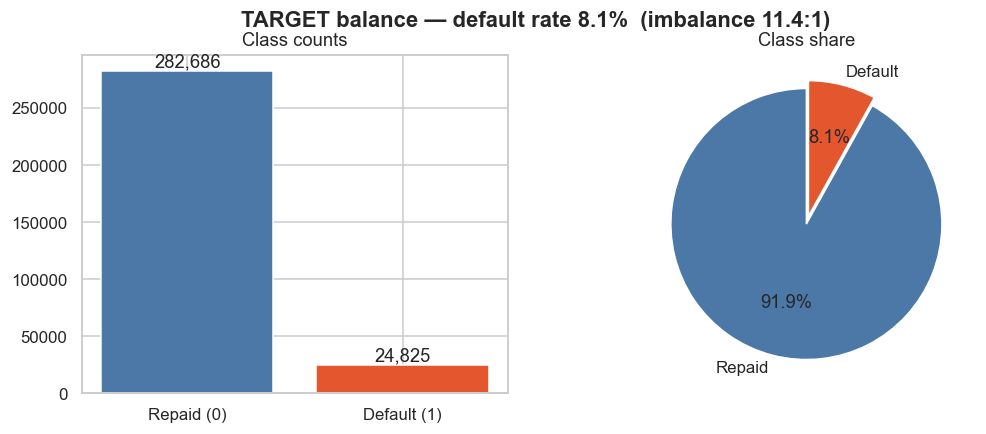

In [3]:
counts = eda[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
bars = ax[0].bar(["Repaid (0)", "Default (1)"], counts.values,
                 color=[PALETTE[0], PALETTE[1]])
ax[0].set_title("Class counts")
ax[0].bar_label(bars, fmt="{:,.0f}")
ax[1].pie(counts.values, labels=["Repaid", "Default"], autopct="%1.1f%%",
          colors=[PALETTE[0], PALETTE[1]], startangle=90, explode=(0, 0.06))
ax[1].set_title("Class share")
fig.suptitle(f"TARGET balance — default rate {overall_rate:.1%}  (imbalance "
             f"{counts[0]/counts[1]:.1f}:1)", fontweight="bold")
savefig(fig, "01_target_balance.png"); plt.show()


## 2. Distributions of key numeric drivers
Income, credit, annuity, the three external credit scores (`EXT_SOURCE_*`), and applicant age.
`EXT_SOURCE_*` are pre-computed external risk scores and are among the strongest known predictors.

saved -> reports\figures\02_numeric_distributions.png


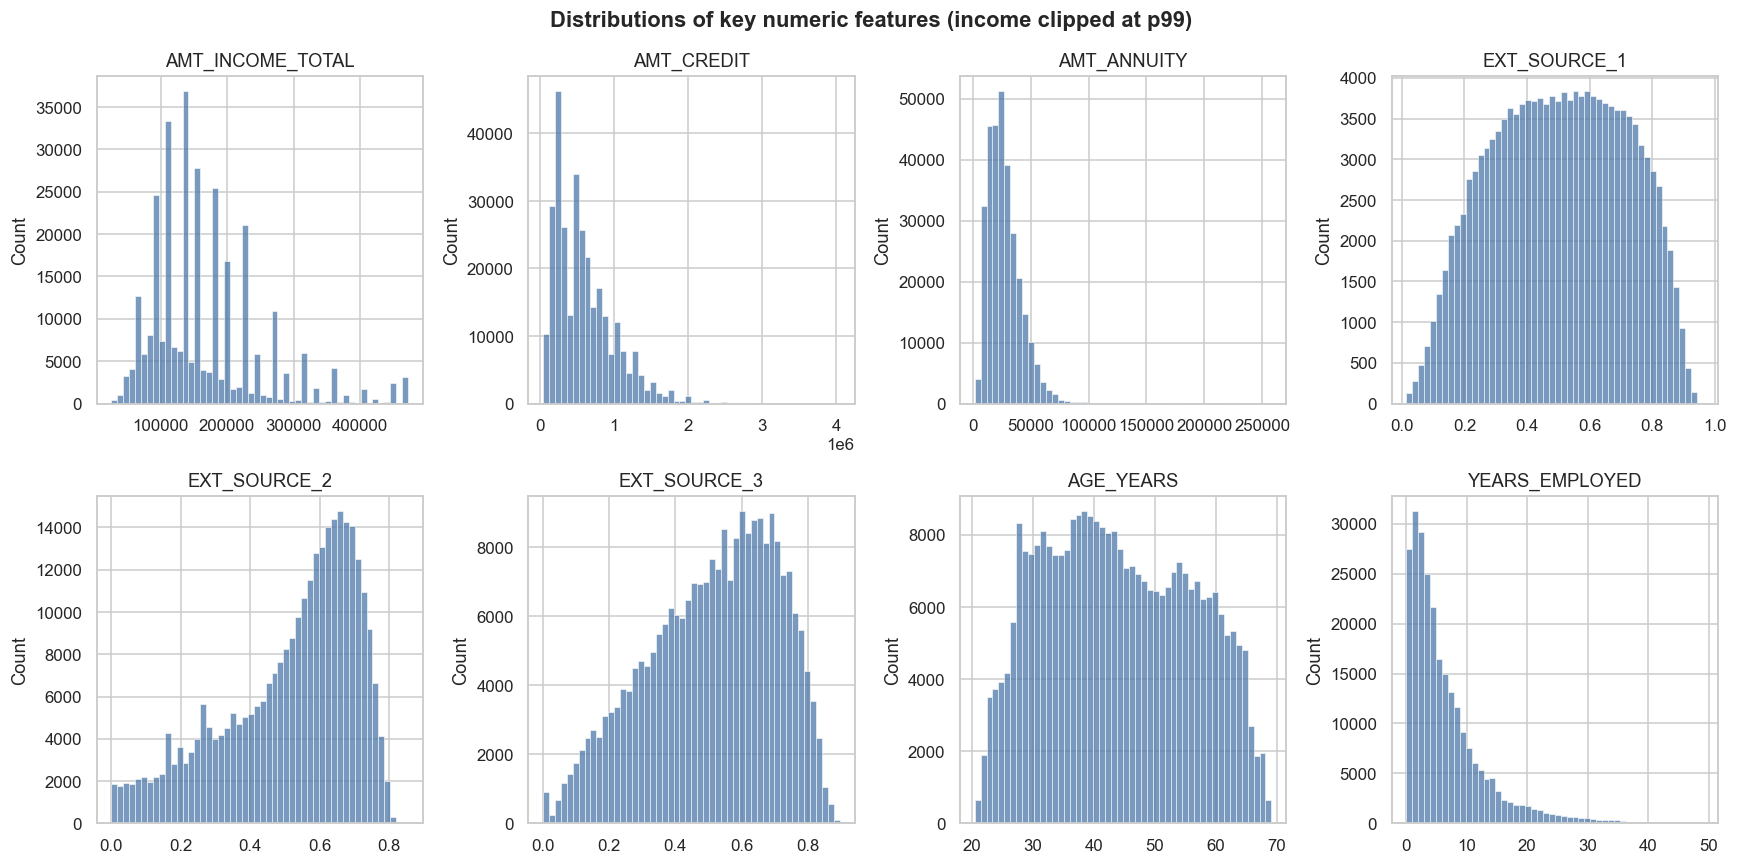

In [4]:
num_feats = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
             "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
             "AGE_YEARS", "YEARS_EMPLOYED"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_feats):
    data = eda[col]
    # clip extreme income tail so the histogram is readable
    if col == "AMT_INCOME_TOTAL":
        data = data.clip(upper=data.quantile(0.99))
    sns.histplot(data.dropna(), bins=50, ax=ax, color="#4C78A8")
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle("Distributions of key numeric features (income clipped at p99)",
             fontweight="bold")
fig.tight_layout()
savefig(fig, "02_numeric_distributions.png"); plt.show()


### 2b. Do the strongest scores separate the classes?
Overlaid distributions of `EXT_SOURCE_*` and age by outcome. Clear separation = predictive signal.

saved -> reports\figures\03_class_separation.png


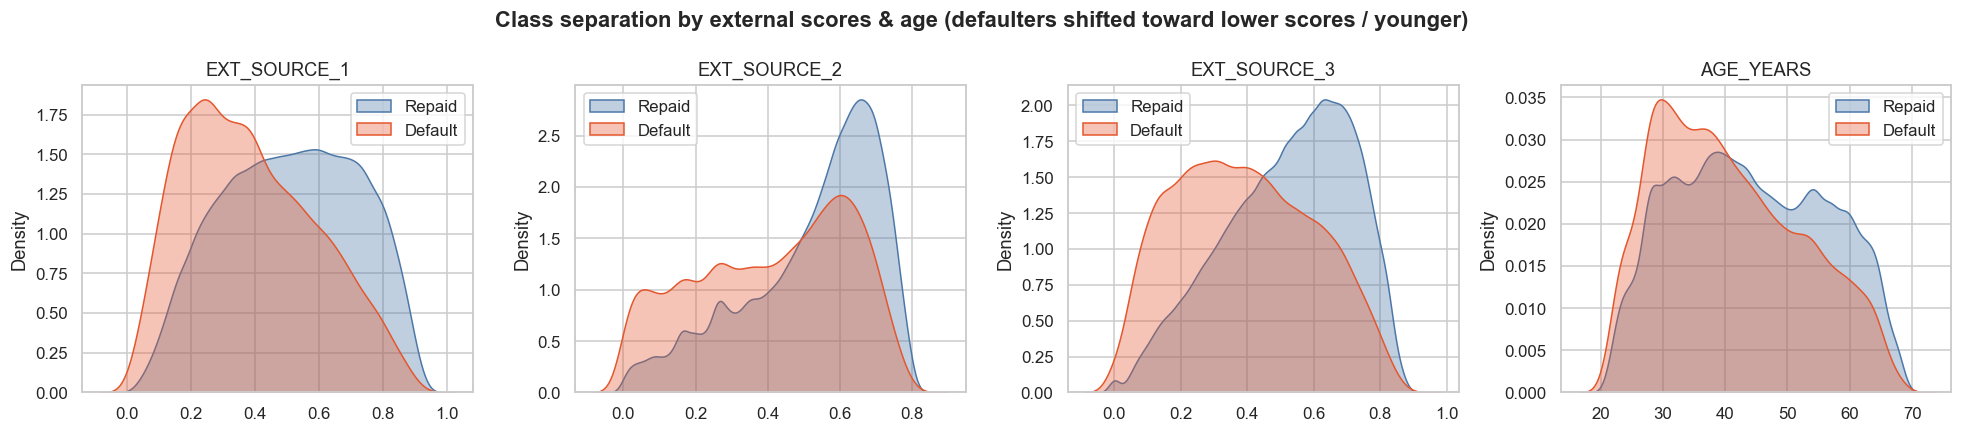

In [5]:
sep_feats = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "AGE_YEARS"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, sep_feats):
    for t in (0, 1):
        sns.kdeplot(eda.loc[eda[TARGET] == t, col].dropna(), ax=ax,
                    label=("Repaid" if t == 0 else "Default"),
                    color=PALETTE[t], fill=True, alpha=0.35)
    ax.set_title(col); ax.set_xlabel(""); ax.legend()
fig.suptitle("Class separation by external scores & age (defaulters shifted "
             "toward lower scores / younger)", fontweight="bold")
fig.tight_layout()
savefig(fig, "03_class_separation.png"); plt.show()


## 3. Default rate across customer groups
For each category we plot the **mean of TARGET = default rate** within the group, against the
overall baseline (dashed). Bars far from the baseline are business-meaningful risk segments.

saved -> reports\figures\04_default_rate_by_group.png


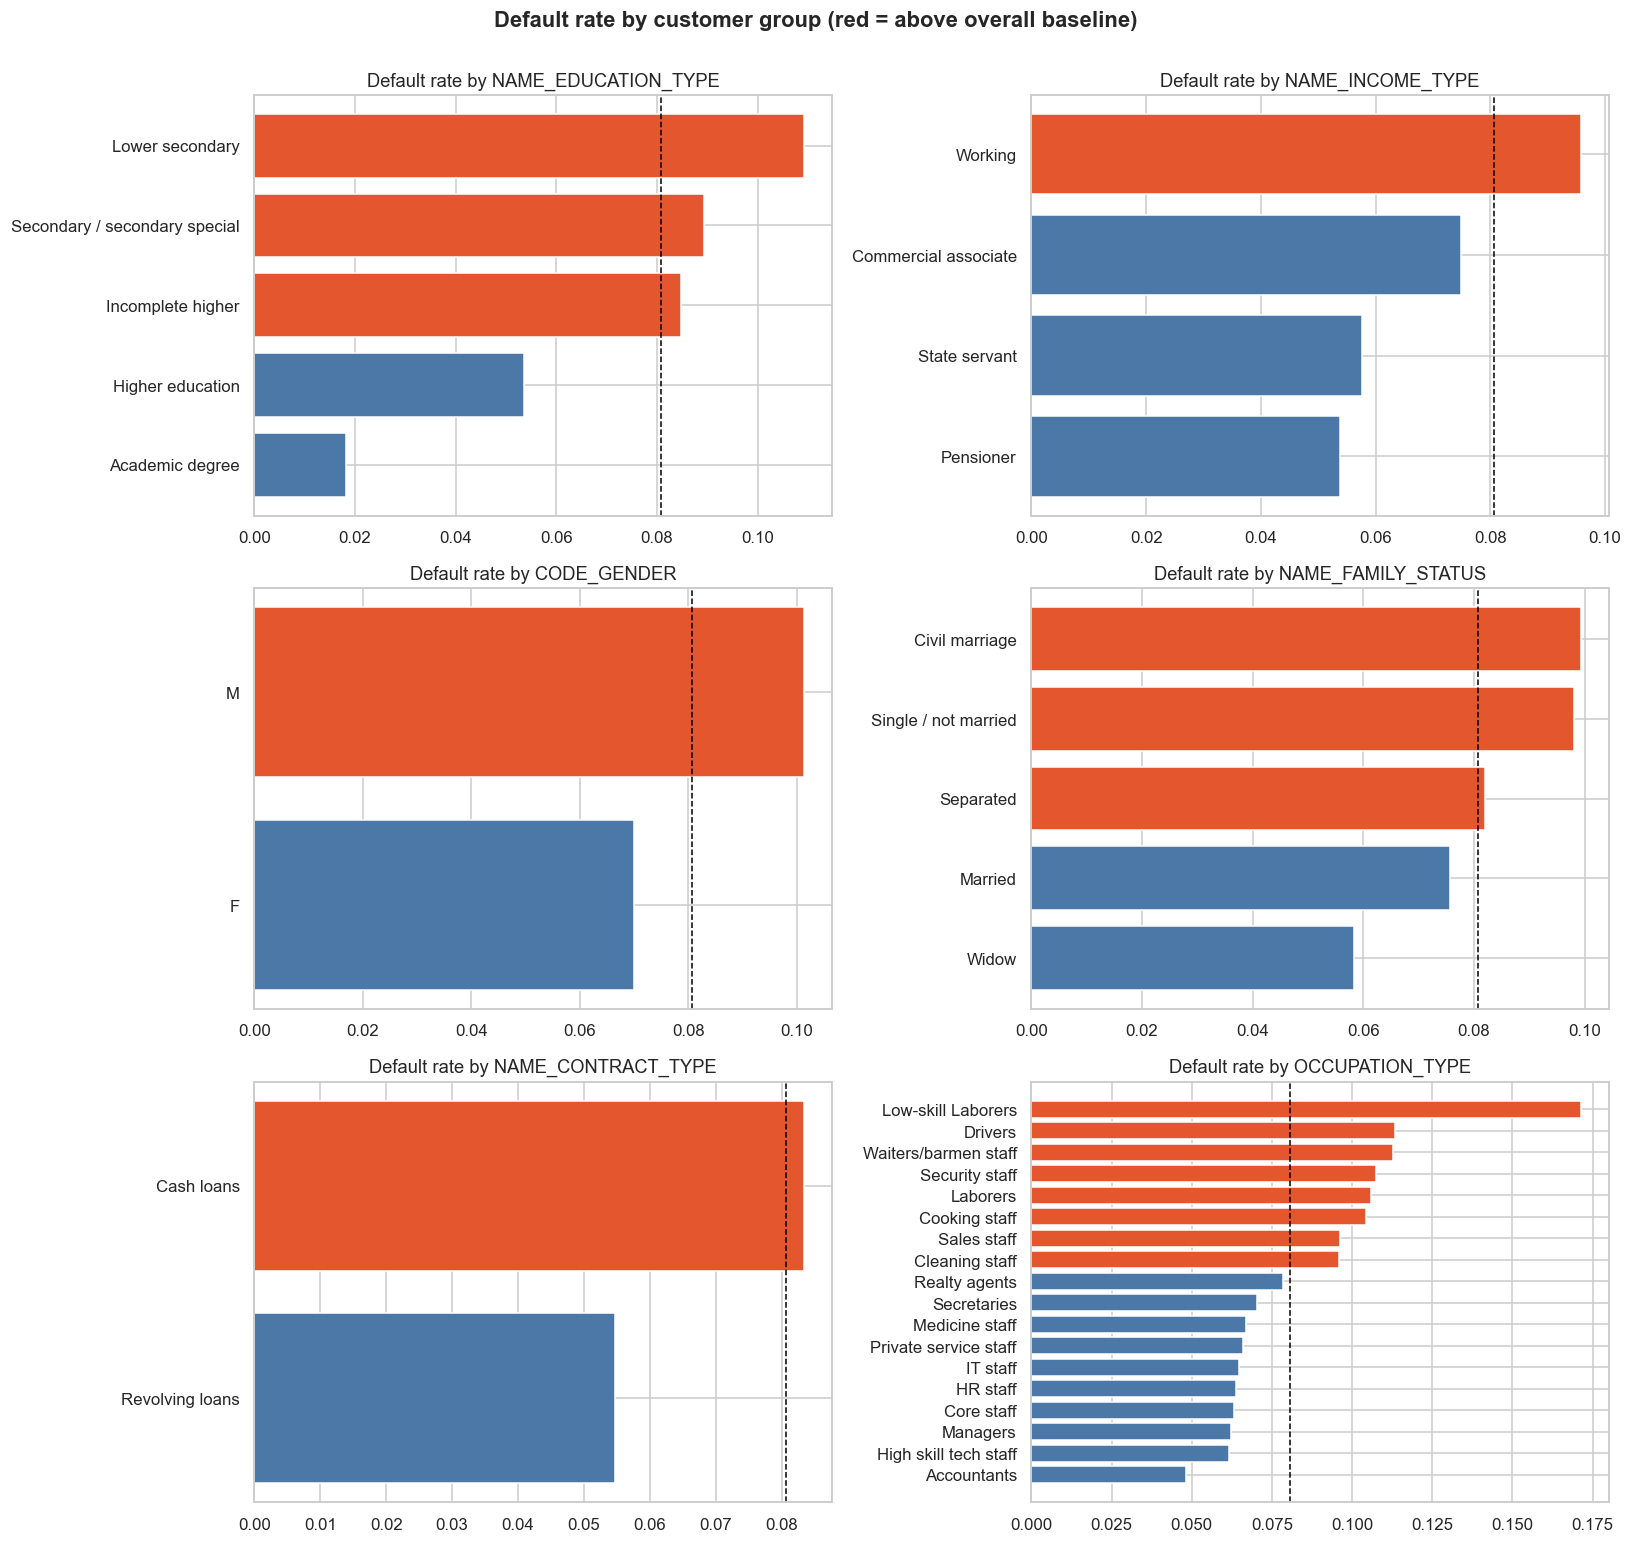

In [6]:
cat_feats = ["NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE", "CODE_GENDER",
             "NAME_FAMILY_STATUS", "NAME_CONTRACT_TYPE", "OCCUPATION_TYPE"]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
for ax, col in zip(axes.ravel(), cat_feats):
    grp = (eda.groupby(col)[TARGET]
             .agg(["mean", "count"])
             .sort_values("mean", ascending=False))
    grp = grp[grp["count"] >= 100]        # ignore tiny groups
    colors = ["#E4572E" if m > overall_rate else "#4C78A8" for m in grp["mean"]]
    ax.barh(grp.index.astype(str), grp["mean"], color=colors)
    ax.axvline(overall_rate, ls="--", color="black", lw=1)
    ax.set_title(f"Default rate by {col}")
    ax.invert_yaxis()
fig.suptitle("Default rate by customer group (red = above overall baseline)",
             fontweight="bold", y=1.001)
fig.tight_layout()
savefig(fig, "04_default_rate_by_group.png"); plt.show()


## 4. Correlation of numeric features with default
Point-biserial (Pearson with a 0/1 target) — magnitude, not causation. The strongest are the
external scores (negative: higher score → lower default) plus a few demographic/loan features.

saved -> reports\figures\05_target_correlation.png


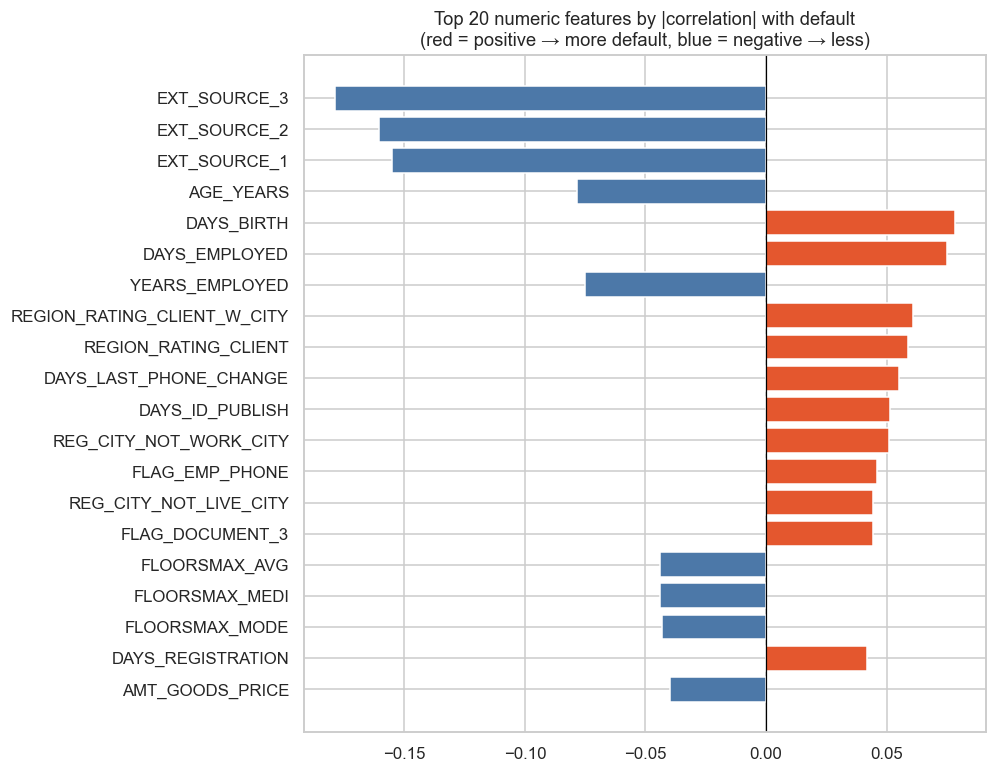

EXT_SOURCE_3                  -0.179
EXT_SOURCE_2                  -0.160
EXT_SOURCE_1                  -0.155
AGE_YEARS                     -0.078
DAYS_BIRTH                     0.078
DAYS_EMPLOYED                  0.075
YEARS_EMPLOYED                -0.075
REGION_RATING_CLIENT_W_CITY    0.061
REGION_RATING_CLIENT           0.059
DAYS_LAST_PHONE_CHANGE         0.055
DAYS_ID_PUBLISH                0.051
REG_CITY_NOT_WORK_CITY         0.051
FLAG_EMP_PHONE                 0.046
REG_CITY_NOT_LIVE_CITY         0.044
FLAG_DOCUMENT_3                0.044
FLOORSMAX_AVG                 -0.044
FLOORSMAX_MEDI                -0.044
FLOORSMAX_MODE                -0.043
DAYS_REGISTRATION              0.042
AMT_GOODS_PRICE               -0.040
dtype: float64


In [7]:
num_df = eda.select_dtypes(include=[np.number]).drop(columns=[cfg['data']['id_column']],
                                                       errors='ignore')
corr = num_df.corrwith(eda[TARGET]).drop(labels=[TARGET], errors='ignore')
top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(20)
fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#E4572E" if v > 0 else "#4C78A8" for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 20 numeric features by |correlation| with default\n"
             "(red = positive → more default, blue = negative → less)")
ax.invert_yaxis()
savefig(fig, "05_target_correlation.png"); plt.show()
print(top.round(3))


## 5. Missingness
Where is data missing? Some columns (housing block, `OWN_CAR_AGE`, `EXT_SOURCE_1`) are 50-70%
missing. Missingness can itself be informative → Stage C adds missing-indicators.

saved -> reports\figures\06_missingness.png


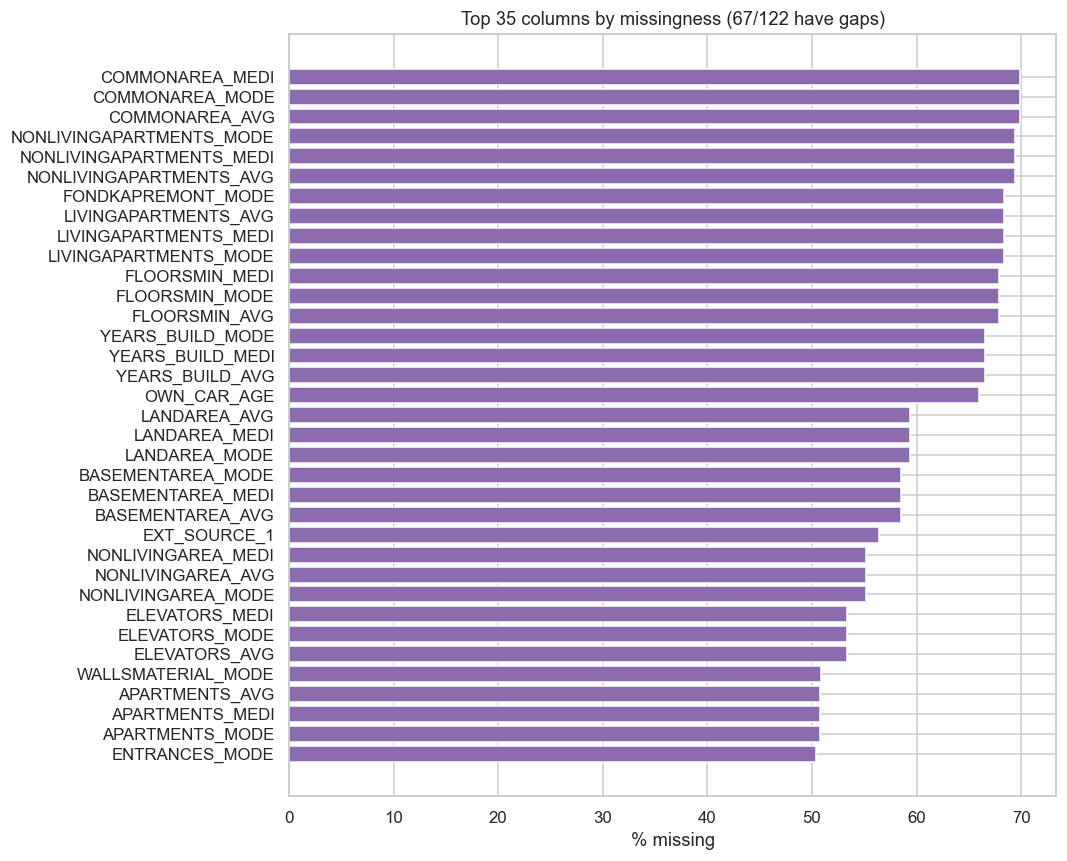

In [8]:
miss = (df.isna().mean() * 100)
miss = miss[miss > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 9))
top_miss = miss.head(35)
ax.barh(top_miss.index, top_miss.values, color="#8C6BAE")
ax.set_xlabel("% missing"); ax.invert_yaxis()
ax.set_title(f"Top 35 columns by missingness ({(miss>0).sum()}/{df.shape[1]} have gaps)")
savefig(fig, "06_missingness.png"); plt.show()


### 5b. Is missingness related to default?
Compare default rate when `EXT_SOURCE_1` / `OWN_CAR_AGE` are present vs missing. If they differ,
the *fact of being missing* carries signal and we should flag it, not just impute silently.

saved -> reports\figures\07_missingness_vs_default.png


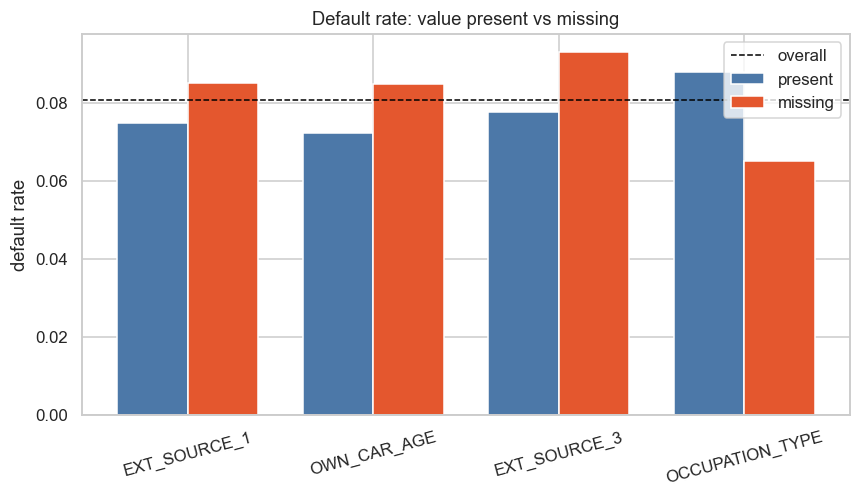

           feature  default_rate_missing  default_rate_present  pct_missing
0     EXT_SOURCE_1                0.0852                0.0750      56.3811
1      OWN_CAR_AGE                0.0850                0.0724      65.9908
2     EXT_SOURCE_3                0.0931                0.0777      19.8253
3  OCCUPATION_TYPE                0.0651                0.0879      31.3455


In [9]:
check = ["EXT_SOURCE_1", "OWN_CAR_AGE", "EXT_SOURCE_3", "OCCUPATION_TYPE"]
rows = []
for c in check:
    m = df[c].isna()
    rows.append({"feature": c,
                 "default_rate_missing": df.loc[m, TARGET].mean(),
                 "default_rate_present": df.loc[~m, TARGET].mean(),
                 "pct_missing": m.mean()*100})
missing_signal = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(check)); w = 0.38
ax.bar(x - w/2, missing_signal["default_rate_present"], w, label="present", color="#4C78A8")
ax.bar(x + w/2, missing_signal["default_rate_missing"], w, label="missing", color="#E4572E")
ax.axhline(overall_rate, ls="--", color="black", lw=1, label="overall")
ax.set_xticks(x); ax.set_xticklabels(check, rotation=15); ax.legend()
ax.set_ylabel("default rate"); ax.set_title("Default rate: value present vs missing")
savefig(fig, "07_missingness_vs_default.png"); plt.show()
print(missing_signal.round(4))


## 6. Outlier / anomaly scan
Confirms the anomalies flagged in Stage 1 and checks amount tails.

DAYS_EMPLOYED == 365243 sentinel rows: 55374 (18.0%)
CODE_GENDER == 'XNA': 4
NAME_FAMILY_STATUS == 'Unknown': 2

AMT_INCOME_TOTAL describe:
count       307511.0
mean        168798.0
std         237123.0
min          25650.0
25%         112500.0
50%         147150.0
75%         202500.0
max      117000000.0
Name: AMT_INCOME_TOTAL, dtype: float64
max income vs p99: 117000000.0 vs 472500.0


saved -> reports\figures\08_outliers.png


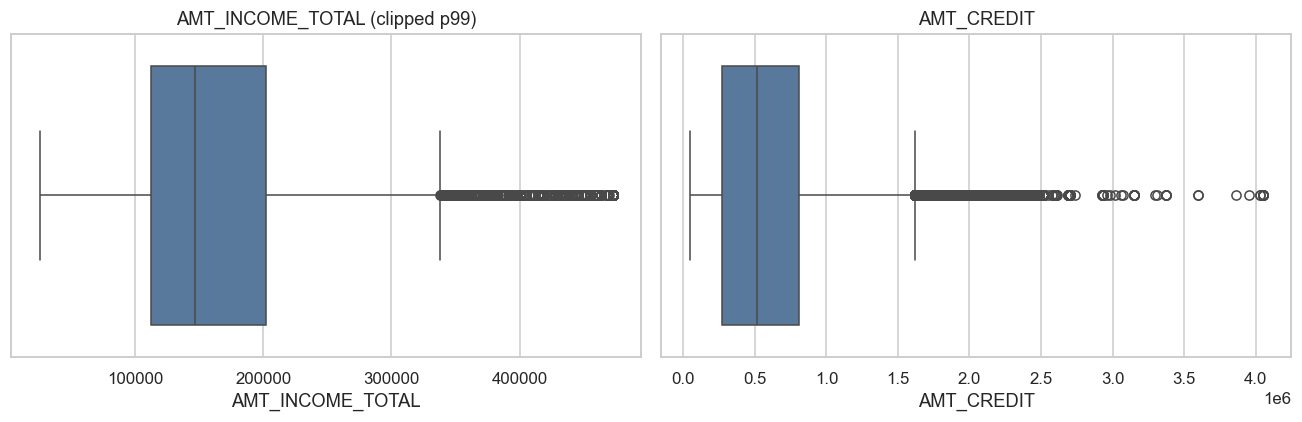

In [10]:
print("DAYS_EMPLOYED == 365243 sentinel rows:",
      int((df['DAYS_EMPLOYED'] == 365243).sum()),
      f"({(df['DAYS_EMPLOYED']==365243).mean()*100:.1f}%)")
print("CODE_GENDER == 'XNA':", int((df['CODE_GENDER']=='XNA').sum()))
print("NAME_FAMILY_STATUS == 'Unknown':", int((df['NAME_FAMILY_STATUS']=='Unknown').sum()))
print("\nAMT_INCOME_TOTAL describe:")
print(df['AMT_INCOME_TOTAL'].describe().round(0))
print("max income vs p99:", df['AMT_INCOME_TOTAL'].max(), "vs",
      df['AMT_INCOME_TOTAL'].quantile(0.99))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['AMT_INCOME_TOTAL'].clip(upper=df['AMT_INCOME_TOTAL'].quantile(0.99)),
            ax=ax[0], color="#4C78A8")
ax[0].set_title("AMT_INCOME_TOTAL (clipped p99)")
sns.boxplot(x=eda['AMT_CREDIT'], ax=ax[1], color="#4C78A8")
ax[1].set_title("AMT_CREDIT")
fig.tight_layout()
savefig(fig, "08_outliers.png"); plt.show()


## 7. Takeaways for later stages
- **Imbalance ~8%** → ROC-AUC + PR-AUC, `class_weight` / `scale_pos_weight`; not accuracy.
- **`EXT_SOURCE_1/2/3`** are the strongest single signals (negative correlation) but heavily
  missing → careful imputation **plus missing-indicators**.
- **Risk segments**: lower education, certain income types (e.g. unemployed/maternity),
  cash vs revolving loans, some occupations show clearly elevated default rates.
- **Missingness is informative** (default rate differs present vs missing) → flag it in Stage C.
- **Anomalies confirmed**: `DAYS_EMPLOYED=365243` (18%), `XNA` gender, `Unknown` family status;
  long income tail → robust (median) imputation and tree models that tolerate outliers.
- These motivate the **feature-engineering** ratios in Stage D (credit/income, annuity/income,
  employment/age, etc.).
